# 🧠🤖 第4周-Day1：RAG基本流程与架构

今天我们开启W4的RAG之旅！🚀 RAG（Retrieval-Augmented Generation）是解决大模型知识局限性的关键技术，让AI能像翻书一样使用外部知识库。

## 📈 学习目标
- 理解RAG的基本概念和价值
- 掌握RAG的四步核心流程
- 熟悉RAG的核心组件和技术栈
- 建立RAG架构的整体认知

使用字体: Noto Sans CJK JP


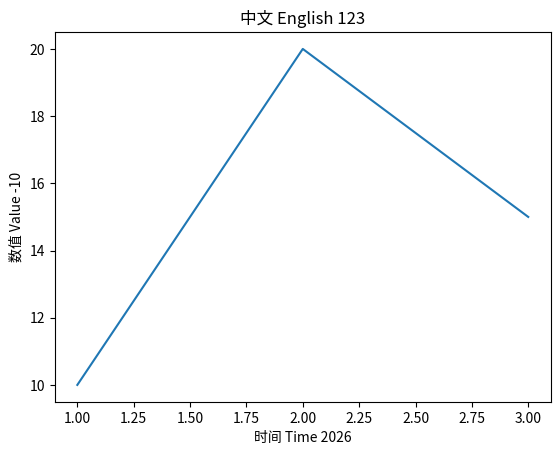

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

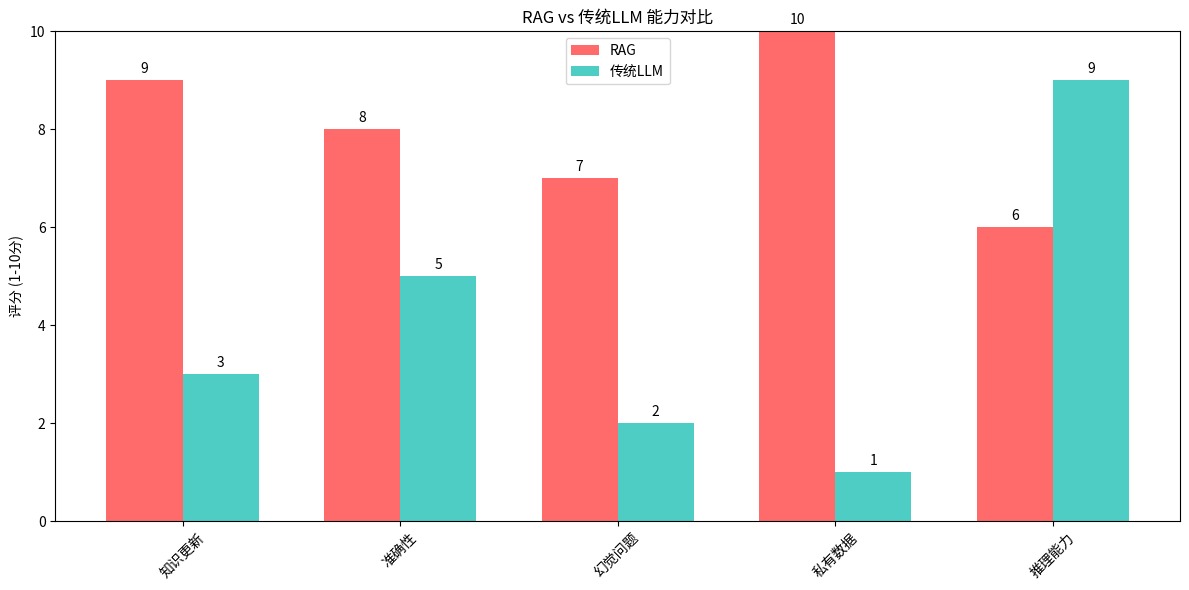

In [2]:
# 📊 RAG vs 传统LLM对比
import matplotlib.pyplot as plt
import numpy as np

# 创建对比数据
categories = ['知识更新', '准确性', '幻觉问题', '私有数据', '推理能力']
rag_scores = [9, 8, 7, 10, 6]
llm_scores = [3, 5, 2, 1, 9]

# 绘制对比图
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, rag_scores, width, label='RAG', color='#ff6b6b')
rects2 = ax.bar(x + width/2, llm_scores, width, label='传统LLM', color='#4ecdc4')

ax.set_ylabel('评分 (1-10分)')
ax.set_title('RAG vs 传统LLM 能力对比')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45)
ax.legend()
ax.set_ylim(0, 10)

# 添加数值标签
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                   xy=(rect.get_x() + rect.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()

## 🔍 RAG核心流程：四步走

RAG的核心是「先检索，后生成」，让AI从外部知识库中获取相关信息，然后结合这些信息回答问题。这个过程分为四个关键步骤：

### Step 1: 📄 文档收集和切割
**目标**：把原始文档变成可检索的小片段

```python
# 文档切割示例
def chunk_documents(texts, chunk_size=512):
    """
    将大文档切割成小的可检索片段
    """
    chunks = []
    for text in texts:
        # 按语义边界切割（段落优先）
        paragraphs = text.split('\n\n')
        for paragraph in paragraphs:
            if len(paragraph) > chunk_size:
                # 超长段落递归切割
                chunks.extend([paragraph[i:i+chunk_size] for i in range(0, len(paragraph), chunk_size)])
            else:
                chunks.append(paragraph)
    return chunks
```

**切割策略对比：**
• 固定大小切割：简单快速，但可能切断语义
• 语义边界切割：保留逻辑，适合结构化文档
• 递归分割：灵活但复杂

/tmp/ipykernel_175715/1750917215.py:37: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


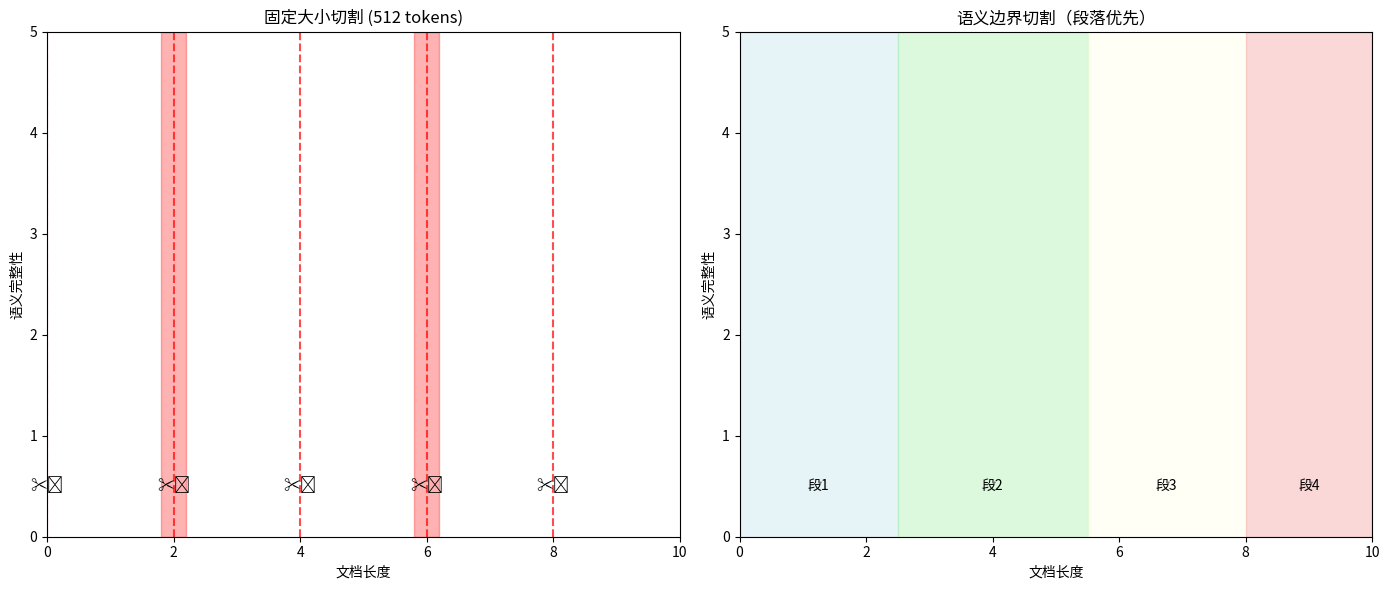

📝 总结：语义边界切割更适合保持内容逻辑性


In [3]:
# 📐 文档切割可视化
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 固定大小切割
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 5)
ax1.set_title('固定大小切割 (512 tokens)')
ax1.set_xlabel('文档长度')
ax1.set_ylabel('语义完整性')

# 绘制切割线
for i in range(0, 10, 2):  # 每2个单位切割一次
    ax1.axvline(x=i, color='red', linestyle='--', alpha=0.7)
    ax1.text(i, 0.5, '✂️', ha='center', va='center', fontsize=12)

# 绘制语义损失区域
ax1.add_patch(patches.Rectangle((1.8, 0), 0.4, 5, alpha=0.3, color='red', label='语义断裂'))
ax1.add_patch(patches.Rectangle((5.8, 0), 0.4, 5, alpha=0.3, color='red'))

# 语义边界切割
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 5)
ax2.set_title('语义边界切割（段落优先）')
ax2.set_xlabel('文档长度')
ax2.set_ylabel('语义完整性')

# 绘制自然段落边界
paragraphs = [(0, 2.5), (2.5, 5.5), (5.5, 8), (8, 10)]
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

for i, (start, end) in enumerate(paragraphs):
    ax2.axvspan(start, end, alpha=0.3, color=colors[i])
    ax2.text((start + end)/2, 0.5, f'段{i+1}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("📝 总结：语义边界切割更适合保持内容逻辑性")

### Step 2: 🧠 向量转换和存储
**目标**：把文本变成AI能理解的数学向量

```python
# 向量化示例
import numpy as np
from sentence_transformers import SentenceTransformer

# 加载预训练的embedding模型
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def embed_documents(chunks):
    """
    将文本片段转换为向量
    """
    vectors = model.encode(chunks)
    return vectors
```

**Embedding核心价值：**
• 将语义相似的内容映射到相近的数学空间
• 支持「以义搜义」而非简单关键词匹配
• 不同模态（文本、图像、音频）都可以向量化

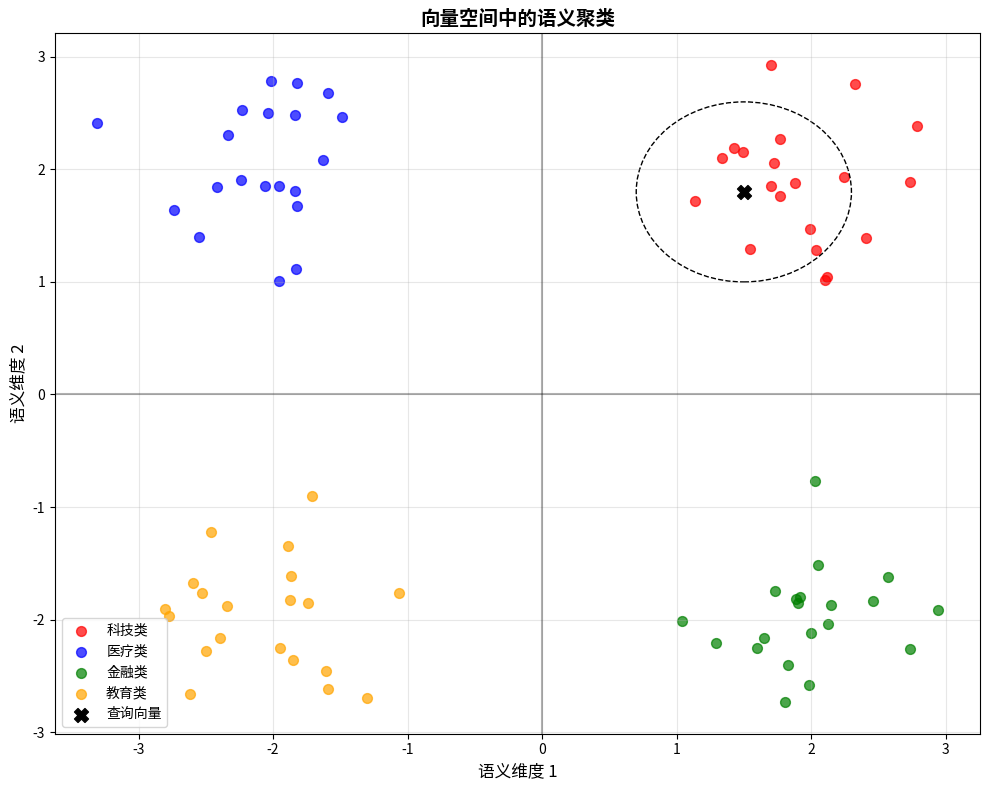

🔍 观察点：
• 同主题的向量在空间中聚集
• 查询向量能找到最相近的语义集群
• 这就是RAG检索的数学基础！


In [4]:
# 🎯 向量空间可视化
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据：不同主题的向量表示
np.random.seed(42)

# "科技类" 向量（集中在右上象限）
tech_vectors = np.random.normal([2, 2], [0.5, 0.5], (20, 2))

# "医疗类" 向量（集中在左上象限）
medical_vectors = np.random.normal([-2, 2], [0.5, 0.5], (20, 2))

# "金融类" 向量（集中在右下象限）
finance_vectors = np.random.normal([2, -2], [0.5, 0.5], (20, 2))

# "教育类" 向量（集中在左下象限）
education_vectors = np.random.normal([-2, -2], [0.5, 0.5], (20, 2))

plt.figure(figsize=(10, 8))

# 绘制不同类别的向量点
plt.scatter(tech_vectors[:, 0], tech_vectors[:, 1], 
            c='red', alpha=0.7, s=50, label='科技类')
plt.scatter(medical_vectors[:, 0], medical_vectors[:, 1], 
            c='blue', alpha=0.7, s=50, label='医疗类')
plt.scatter(finance_vectors[:, 0], finance_vectors[:, 1], 
            c='green', alpha=0.7, s=50, label='金融类')
plt.scatter(education_vectors[:, 0], education_vectors[:, 1], 
            c='orange', alpha=0.7, s=50, label='教育类')

# 添加示例查询向量
query_vector = np.array([1.5, 1.8])
plt.scatter(query_vector[0], query_vector[1], 
            c='black', s=100, marker='X', label='查询向量')

# 添加距离圈圈
circle = plt.Circle(query_vector, 0.8, fill=False, color='black', linestyle='--')
plt.gca().add_patch(circle)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.title('向量空间中的语义聚类', fontsize=14, fontweight='bold')
plt.xlabel('语义维度 1', fontsize=12)
plt.ylabel('语义维度 2', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🔍 观察点：\n• 同主题的向量在空间中聚集\n• 查询向量能找到最相近的语义集群\n• 这就是RAG检索的数学基础！")

### Step 3: 🔍 文档过滤和检索
**目标**：从海量文档中找到最相关的知识片段

```python
# 向量检索示例
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def search_relevant_documents(query_vector, document_vectors, top_k=5):
    """
    计算查询向量与文档向量的相似度，返回最相关的文档
    """
    similarities = cosine_similarity([query_vector], document_vectors)[0]
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    return top_indices, similarities[top_indices]
```

**相似度计算方法：**
• 余弦相似度：衡量向量方向的一致性（0-1，1表示完全相似）
• 欧氏距离：衡量向量在空间中的绝对距离
• 余弦距离：1 - 余弦相似度

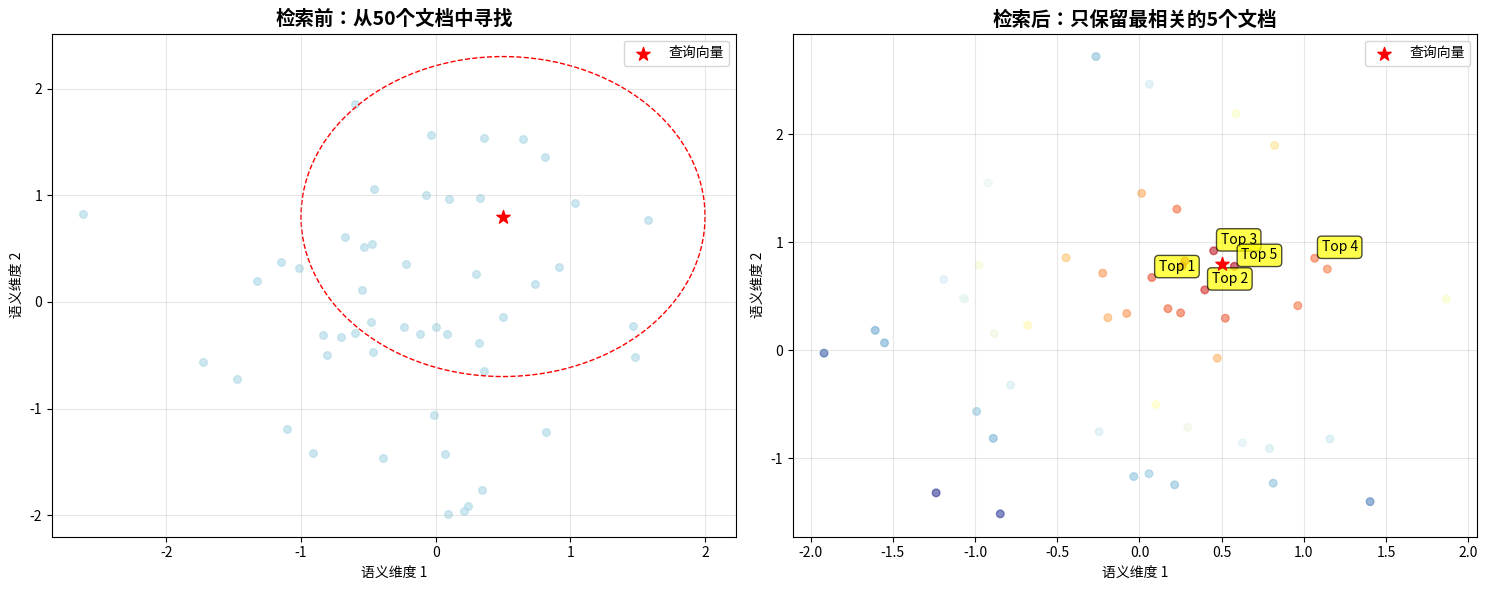

🎯 RAG检索优势：
• 从50个文档中精准找到最相关的5个
• 基于语义相似性而非简单关键词匹配
• 大幅减少上下文长度限制的影响


In [5]:
# 🔍 检索过程可视化
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 第一个子图：检索前 - 所有文档向量
np.random.seed(42)
num_documents = 50
document_vectors = np.random.randn(num_documents, 2)

# 随机分布文档向量
scatter1 = ax1.scatter(document_vectors[:, 0], document_vectors[:, 1], 
                      alpha=0.6, s=30, c='lightblue')

# 查询向量（红色）
query_vec = np.array([0.5, 0.8])
ax1.scatter(query_vec[0], query_vec[1], color='red', s=100, 
          marker='*', label='查询向量', zorder=5)

# 绘制距离圈圈表示检索范围
circle1 = plt.Circle(query_vec, 1.5, fill=False, color='red', linestyle='--')
ax1.add_patch(circle1)

ax1.set_title('检索前：从50个文档中寻找', fontsize=14, fontweight='bold')
ax1.set_xlabel('语义维度 1')
ax1.set_ylabel('语义维度 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 第二个子图：检索后 - 只显示最相关的5个文档
# 重新生成一些文档，确保有接近查询的
relevant_docs = np.random.normal([0.5, 0.8], [0.3, 0.3], (5, 2))
irrelevant_docs = np.random.randn(45, 2)  # 远离查询的文档
filtered_vectors = np.vstack([relevant_docs, irrelevant_docs])

# 按距离着色：越近越红，越远越蓝
distances = np.sqrt(np.sum((filtered_vectors - query_vec)**2, axis=1))
colors = plt.cm.RdYlBu_r(1 - distances / np.max(distances))

scatter2 = ax2.scatter(filtered_vectors[:, 0], filtered_vectors[:, 1], 
                      alpha=0.6, s=30, c=colors)
ax2.scatter(query_vec[0], query_vec[1], color='red', s=100, 
          marker='*', label='查询向量', zorder=5)

# 标记最相关的5个文档
for i in range(5):
    ax2.annotate(f'Top {i+1}', (relevant_docs[i, 0], relevant_docs[i, 1]),
                xytext=(5, 5), textcoords='offset points', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.set_title('检索后：只保留最相关的5个文档', fontsize=14, fontweight='bold')
ax2.set_xlabel('语义维度 1')
ax2.set_ylabel('语义维度 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 RAG检索优势：\n• 从50个文档中精准找到最相关的5个\n• 基于语义相似性而非简单关键词匹配\n• 大幅减少上下文长度限制的影响")

### Step 4: 🎯 查询增强和关联
**目标**：结合检索到的知识生成高质量的回答

```python
# 查询增强示例
def create_enhanced_prompt(query, retrieved_docs):
    """
    构建增强的提示词，结合用户问题和检索到的文档
    """
    context = "\n\n".join([f"文档{i+1}: {doc}" for i, doc in enumerate(retrieved_docs)])
    
    prompt = f"""基于以下文档信息，请回答用户的问题：

用户问题：{query}

相关文档：
{context}

回答要求：
1. 基于文档内容回答，不要编造信息
2. 引用具体的文档来源
3. 回答要简洁明了
"""
    return prompt
```

**关键技巧：**
• 平衡用户问题和文档知识的权重
• 添加来源引用提升可信度
• 使用指示词引导模型合理使用检索内容

/tmp/ipykernel_175715/2502085566.py:142: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


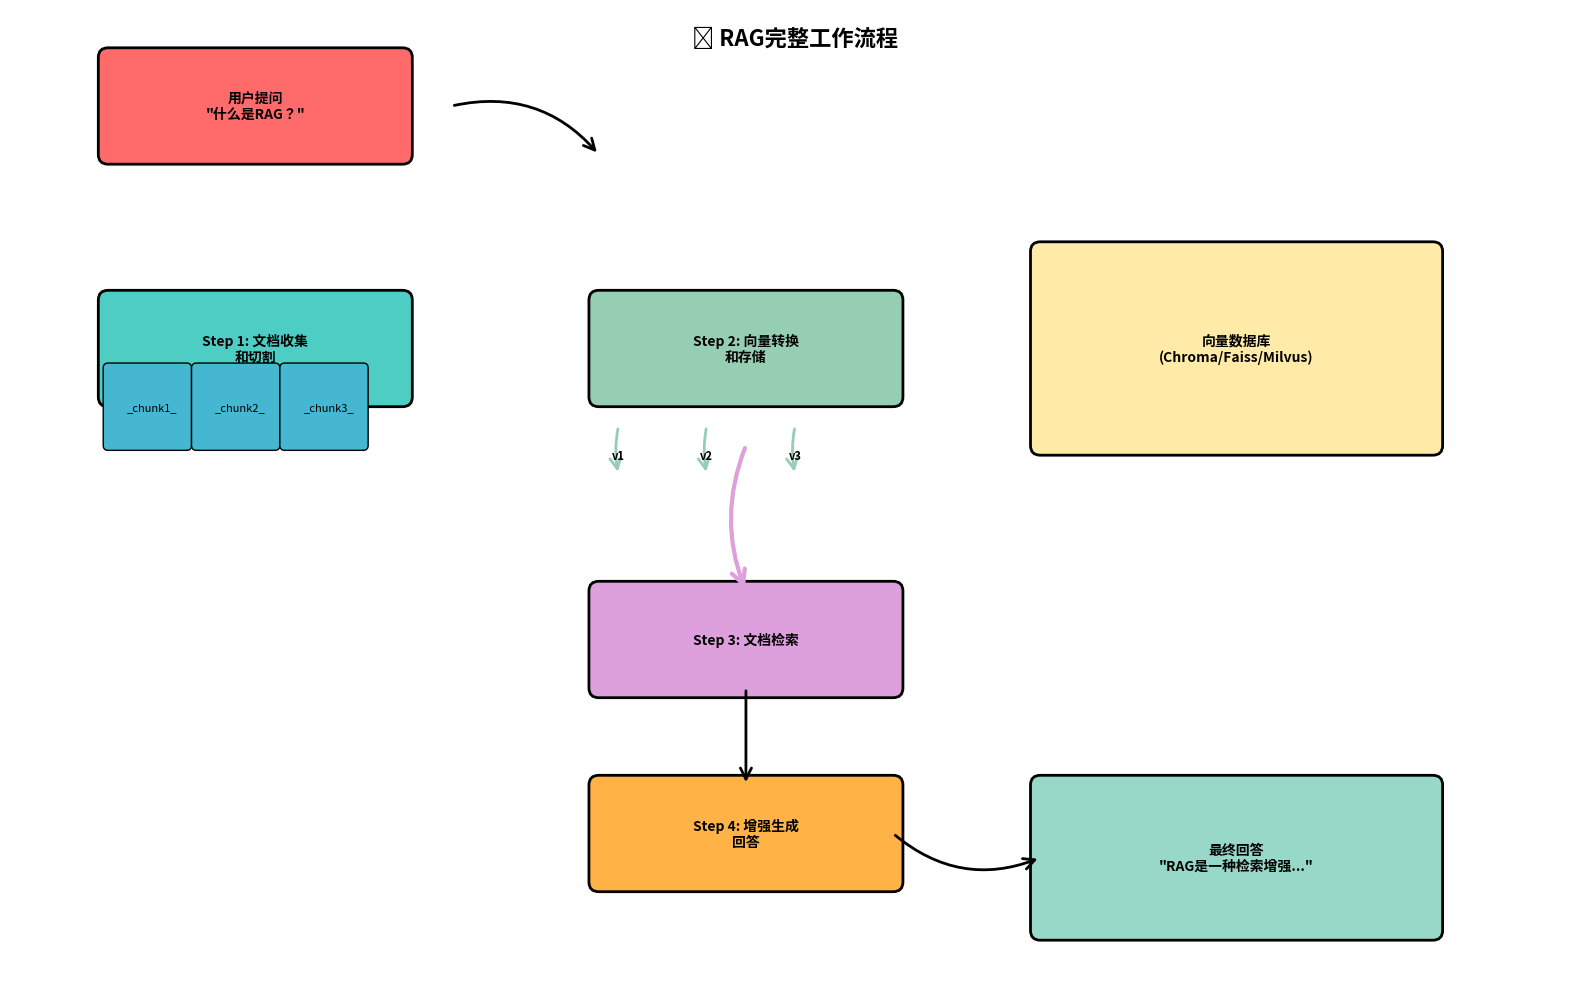

🎯 RAG优势总结：
✅ 知识实时更新：不受训练数据限制
✅ 专业准确：基于外部知识减少幻觉
✅ 私有数据支持：可以处理企业内部文档
✅ 可解释性强：回答可以追溯来源
✅ 成本可控：不用重新训练大模型


In [6]:
# 📋 RAG流程完整可视化
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# 定义颜色
colors = {
    'query': '#FF6B6B',
    'docs': '#4ECDC4',
    'chunks': '#45B7D1',
    'embed': '#96CEB4',
    'vector_db': '#FFEAA7',
    'retrieval': '#DDA0DD',
    'llm': '#FFB347',
    'answer': '#98D8C8'
}

# 用户输入
query_box = FancyBboxPatch((1, 8.5), 3, 1, 
                          boxstyle="round,pad=0.1", 
                          facecolor=colors['query'], 
                          edgecolor='black', linewidth=2)
ax.add_patch(query_box)
ax.text(2.5, 9, '用户提问\n"什么是RAG？"', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# Step 1: 文档处理
doc_box = FancyBboxPatch((1, 6), 3, 1, 
                        boxstyle="round,pad=0.1", 
                        facecolor=colors['docs'], 
                        edgecolor='black', linewidth=2)
ax.add_patch(doc_box)
ax.text(2.5, 6.5, 'Step 1: 文档收集\n和切割', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# 文档切割示意
chunks = []
for i in range(3):
    chunk = FancyBboxPatch((1 + i*0.9, 5.5), 0.8, 0.8, 
                          boxstyle="round,pad=0.05", 
                          facecolor=colors['chunks'], 
                          edgecolor='black')
    ax.add_patch(chunk)
    ax.text(1.45 + i*0.9, 5.9, f'_chunk{i+1}_', 
            ha='center', va='center', fontsize=8)
    chunks.append(chunk)

# Step 2: 向量化
embed_box = FancyBboxPatch((6, 6), 3, 1, 
                           boxstyle="round,pad=0.1", 
                           facecolor=colors['embed'], 
                           edgecolor='black', linewidth=2)
ax.add_patch(embed_box)
ax.text(7.5, 6.5, 'Step 2: 向量转换\n和存储', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# 向量表示
vectors = []
for i in range(3):
    vec = patches.FancyArrowPatch((6.2 + i*0.9, 5.7), (6.2 + i*0.9, 5.2),
                                  connectionstyle="arc3,rad=0.1",
                                  arrowstyle='->', mutation_scale=20,
                                  color=colors['embed'], linewidth=2)
    ax.add_patch(vec)
    ax.text(6.2 + i*0.9, 5.4, f'v{i+1}', 
            ha='center', va='center', fontsize=8, fontweight='bold')
    vectors.append(vec)

# 向量数据库
db_box = FancyBboxPatch((10.5, 5.5), 4, 2, 
                        boxstyle="round,pad=0.1", 
                        facecolor=colors['vector_db'], 
                        edgecolor='black', linewidth=2)
ax.add_patch(db_box)
ax.text(12.5, 6.5, '向量数据库\n(Chroma/Faiss/Milvus)', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# Step 3: 检索
retrieval_box = FancyBboxPatch((6, 3), 3, 1, 
                               boxstyle="round,pad=0.1", 
                               facecolor=colors['retrieval'], 
                               edgecolor='black', linewidth=2)
ax.add_patch(retrieval_box)
ax.text(7.5, 3.5, 'Step 3: 文档检索', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# 检索箭头
retrieval_arrow = patches.FancyArrowPatch((7.5, 5.5), (7.5, 4),
                                          connectionstyle="arc3,rad=0.2",
                                          arrowstyle='->', mutation_scale=25,
                                          color=colors['retrieval'], linewidth=3)
ax.add_patch(retrieval_arrow)

# Step 4: 生成回答
llm_box = FancyBboxPatch((6, 1), 3, 1, 
                         boxstyle="round,pad=0.1", 
                         facecolor=colors['llm'], 
                         edgecolor='black', linewidth=2)
ax.add_patch(llm_box)
ax.text(7.5, 1.5, 'Step 4: 增强生成\n回答', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# 最终回答
answer_box = FancyBboxPatch((10.5, 0.5), 4, 1.5, 
                           boxstyle="round,pad=0.1", 
                           facecolor=colors['answer'], 
                           edgecolor='black', linewidth=2)
ax.add_patch(answer_box)
ax.text(12.5, 1.25, '最终回答\n"RAG是一种检索增强..."', 
        ha='center', va='center', fontsize=10, fontweight='bold')

# 连接线
flow_arrows = [
    # 查询到检索
    patches.FancyArrowPatch((4.5, 9), (6, 8.5),
                            connectionstyle="arc3,rad=-0.3",
                            arrowstyle='->', mutation_scale=20,
                            color='black', linewidth=2),
    # 检索到LLM
    patches.FancyArrowPatch((7.5, 3), (7.5, 2),
                            arrowstyle='->', mutation_scale=20,
                            color='black', linewidth=2),
    # LLM到回答
    patches.FancyArrowPatch((9, 1.5), (10.5, 1.25),
                            connectionstyle="arc3,rad=0.3",
                            arrowstyle='->', mutation_scale=20,
                            color='black', linewidth=2),
]

for arrow in flow_arrows:
    ax.add_patch(arrow)

# 添加标题
ax.text(8, 9.7, '🧠 RAG完整工作流程', 
        ha='center', va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("🎯 RAG优势总结：\n✅ 知识实时更新：不受训练数据限制\n✅ 专业准确：基于外部知识减少幻觉\n✅ 私有数据支持：可以处理企业内部文档\n✅ 可解释性强：回答可以追溯来源\n✅ 成本可控：不用重新训练大模型")

## 🧩 RAG核心组件技术栈

一个完整的RAG系统由多个组件协同工作：

### 📚 文档处理层
• **文档加载器**：支持PDF、Word、HTML、TXT等多种格式
• **文档切割器**：智能分块策略，保持语义完整性
• **文本清洗器**：去除噪声，标准化文本格式

### 🧠 向量化层
• **Embedding模型**：
  - 中文：text2vec-base, bge-large-zh
  - 英文：text-embedding-ada-002, sentence-transformers
  - 多语言：paraphrase-multilingual
• **向量维度**：通常384-768维，平衡精度和性能

### 🗄️ 存储检索层
• **向量数据库**：
  - 轻量级：ChromaDB, FAISS（适合开发环境）
  - 企业级：Milvus, Pinecone, Qdrant（适合生产环境）
  - 传统库扩展：PostgreSQL + pgvector, Redis + RediSearch

### 🔍 检索增强层
• **检索策略**：
  - 纯语义检索：基于向量相似度
  - 混合检索：关键词 + 语义结合
  - 重排序（Reranking）：用更精细的算法优化结果

### 🎯 生成输出层
• **大模型**：
  - 开源：Qwen2, Llama3, ChatGLM3
  - 商业：GPT-4, Claude 3, Gemini
• **提示词工程**：合理引导模型利用检索内容

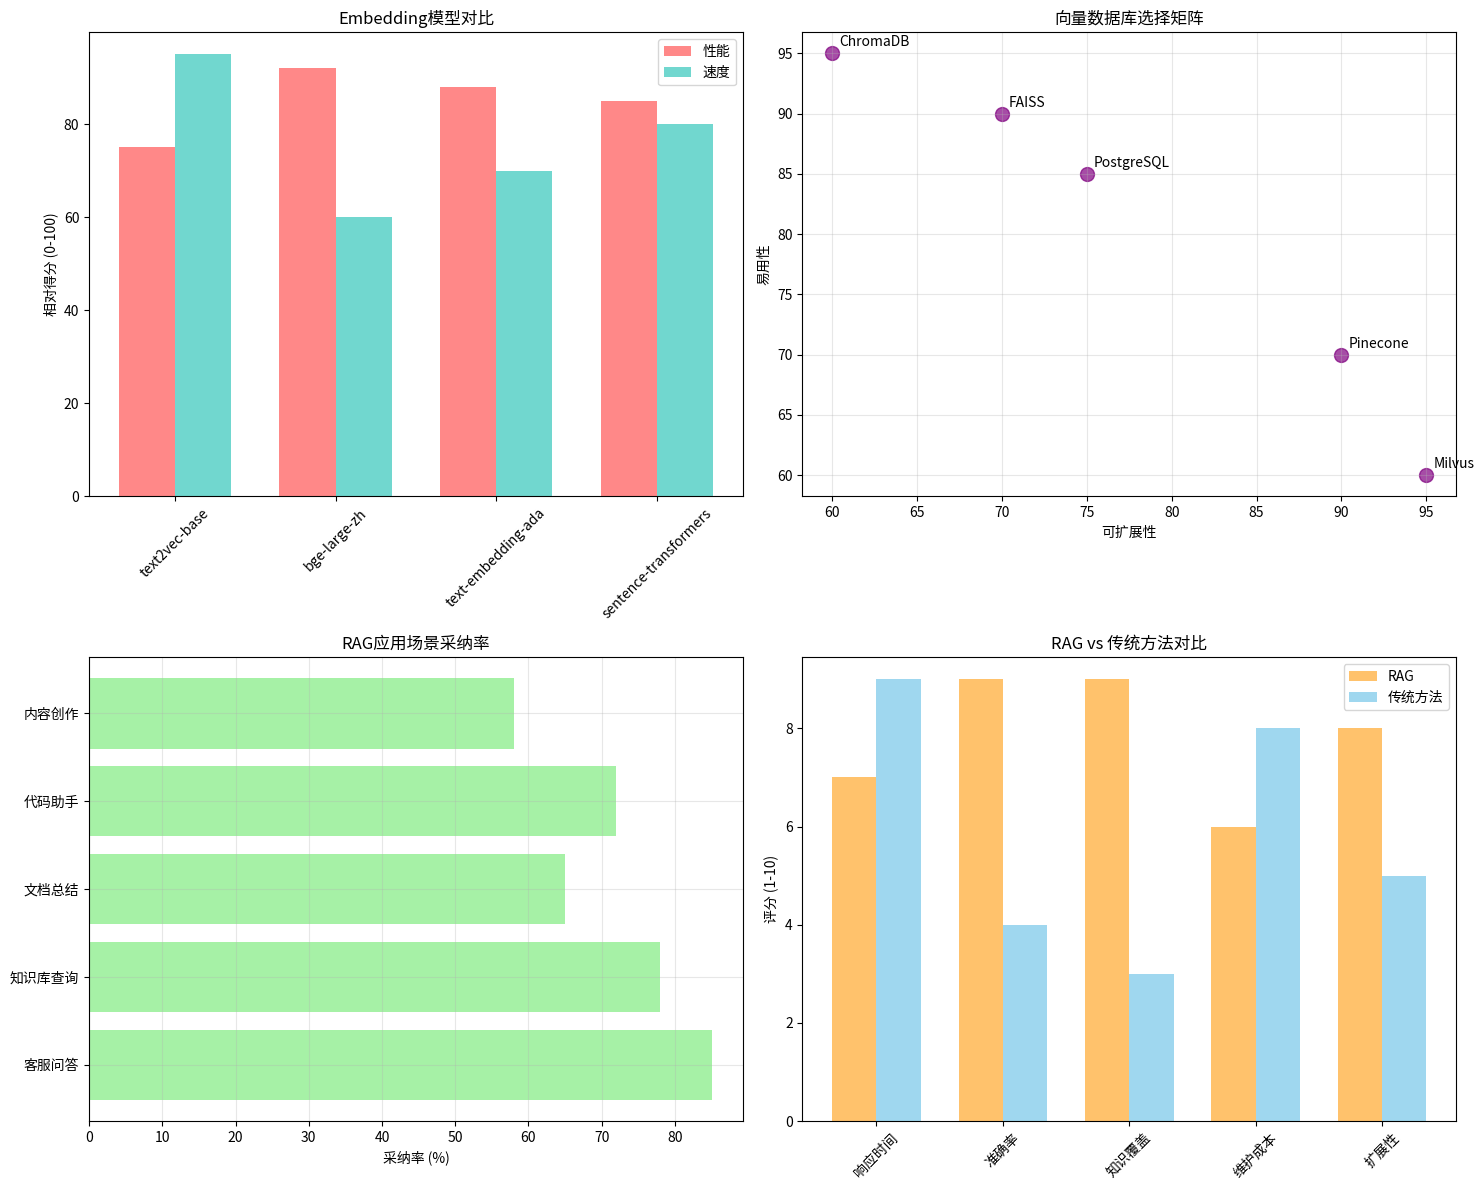

📊 技术栈选择建议：
• 开发环境：ChromaDB + text2vec-base + Qwen2
• 生产环境：Milvus + bge-large-zh + GPT-4
• 成本敏感：FAISS + sentence-transformers + Llama3
• 中文场景：text2vec系列模型效果最佳


In [8]:
# 🛠️ RAG技术栈选择可视化
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Embedding模型性能对比
models = ['text2vec-base', 'bge-large-zh', 'text-embedding-ada', 'sentence-transformers']
performance = [75, 92, 88, 85]
speed = [95, 60, 70, 80]

x = np.arange(len(models))
width = 0.35

ax1.bar(x - width/2, performance, width, label='性能', color='#FF6B6B', alpha=0.8)
ax1.bar(x + width/2, speed, width, label='速度', color='#4ECDC4', alpha=0.8)
ax1.set_title('Embedding模型对比')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45)
ax1.legend()
ax1.set_ylabel('相对得分 (0-100)')

# 2. 向量数据库选择矩阵
db_types = ['FAISS', 'ChromaDB', 'Milvus', 'Pinecone', 'PostgreSQL']
scalability = [70, 60, 95, 90, 75]
ease_of_use = [90, 95, 60, 70, 85]

ax2.scatter(scalability, ease_of_use, s=100, alpha=0.7, c='purple')
for i, db in enumerate(db_types):
    ax2.annotate(db, (scalability[i], ease_of_use[i]), 
                xytext=(5, 5), textcoords='offset points')
ax2.set_xlabel('可扩展性')
ax2.set_ylabel('易用性')
ax2.set_title('向量数据库选择矩阵')
ax2.grid(True, alpha=0.3)

# 3. RAG应用场景分布
scenarios = ['客服问答', '知识库查询', '文档总结', '代码助手', '内容创作']
adoption_rate = [85, 78, 65, 72, 58]

ax3.barh(scenarios, adoption_rate, color='lightgreen', alpha=0.8)
ax3.set_title('RAG应用场景采纳率')
ax3.set_xlabel('采纳率 (%)')
ax3.grid(True, alpha=0.3)

# 4. RAG vs 传统方法性能对比
metrics = ['响应时间', '准确率', '知识覆盖', '维护成本', '扩展性']
rag_scores = [7, 9, 9, 6, 8]
traditional_scores = [9, 4, 3, 8, 5]

x = np.arange(len(metrics))
width = 0.35

ax4.bar(x - width/2, rag_scores, width, label='RAG', color='#FFB347', alpha=0.8)
ax4.bar(x + width/2, traditional_scores, width, label='传统方法', color='#87CEEB', alpha=0.8)
ax4.set_title('RAG vs 传统方法对比')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, rotation=45)
ax4.legend()
ax4.set_ylabel('评分 (1-10)')

plt.tight_layout()
plt.show()

print("📊 技术栈选择建议：\n"
      "• 开发环境：ChromaDB + text2vec-base + Qwen2\n"
      "• 生产环境：Milvus + bge-large-zh + GPT-4\n"
      "• 成本敏感：FAISS + sentence-transformers + Llama3\n"
      "• 中文场景：text2vec系列模型效果最佳")

## 💡 业务关联思考

### 🎯 糖水店的RAG应用场景

对于美华的糖水店，RAG技术可以应用到这些方面：

1. **📋 产品知识库**
   - 整合所有糖水产品的配方、特点、价格
   - 顾客问"哪个糖水最适合夏天喝？"能精准推荐

2. **📊 营销素材库**
   - 存储过往的推广文案、活动方案
   - 快速生成新的营销内容

3. **💬 客户服务**
   - 记录常见问题和标准回答
   - 提高服务一致性和响应速度

4. **📈 运营分析**
   - 结合销售数据回答经营问题
   - "为什么这个月的绿豆沙销量下降？"

### 🔧 技术实施建议

**轻量级方案**（适合店铺使用）：
• 文档存储：Notion/飞书文档
• 向量数据库：ChromaDB本地部署
• 模型：Qwen2-0.5B本地运行
• 应用：微信小程序内置问答功能

**进阶方案**（适合连锁经营）：
• 云端向量数据库：Milvus/Pinecone
• API服务：腾讯云AI/阿里云AI
• 多店铺数据同步与统一管理

## 🎓 今日总结

### 📝 核心知识点回顾
✅ **RAG基本概念**：检索增强生成，解决大模型知识局限性
✅ **四步核心流程**：文档处理→向量化→检索→生成
✅ **关键技术组件**：Embedding模型、向量数据库、检索策略
✅ **核心价值**：知识实时更新、减少幻觉、支持私有数据

### 🔑 关键术语
- **Embedding** [ˈembɛdɪŋ] 向量表示，将文本转换为数学向量
- **Vector Database** [ˈvɛktər ˈdeɪtəbeɪs] 向量数据库，专门存储和检索向量数据
- **Cosine Similarity** [ˈkoʊsaɪn ˌsɪmɪˈlærɪti] 余弦相似度，衡量向量相似度的方法
- **Chunking** [ˈtʃʌŋkɪŋ] 文档切割，将大文档分割成小的可检索片段
- **Reranking** [ˌriːˈræŋkɪŋ] 重排序，用更精细的算法优化检索结果

### 🚀 下周预告
明天我们将深入W4-Day2，学习**向量检索：Embedding与相似度计算**，详细探讨不同Embedding模型的选型、相似度计算方法，以及如何优化检索效果的实用技巧！

👉 准备好你的好奇心，我们一起探索向量世界的奥秘！